<a href="https://colab.research.google.com/github/Jacopoo0/Boston_Housing_ML_BigData_Analysis/blob/main/Boston_Housing_ML_BigData_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESAME Pratico – Analisi del Dataset BOSTON (ISLP)
**Jacopo_Zucca_Esame_II_anno_BigData**

Il dataset `Boston` contiene le seguenti feature:

- **crim**: tasso di criminalità pro capite per città.
- **zn**: proporzione di terreno residenziale suddiviso in zone per lotti di oltre 25.000 piedi quadrati.
- **indus**: proporzione di acri di affari non al dettaglio per città.
- **chas**: variabile dummy del fiume Charles (1 se il tratto costeggia il fiume; 0 altrimenti).
- **nox**: concentrazione di ossido nitrico (parti per 10 milioni).
- **rm**: numero medio di stanze per abitazione.
- **age**: proporzione di unità occupate dal proprietario costruite prima del 1940.
- **dis**: distanze ponderate da cinque centri di impiego di Boston.
- **rad**: indice di accessibilità alle autostrade radiali.
- **tax**: tasso di imposta sulla proprietà a valore pieno per 10.000 dollari.
- **ptratio**: rapporto alunni-insegnanti per città.
- **lstat**: percentuale di popolazione con basso status socioeconomico.
- **medv**: valore mediano delle abitazioni occupate dal proprietario in migliaia di dollari (la variabile target per la regressione).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,root_mean_squared_error)
import statsmodels.api as sm
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

try:
    import ISLP
except ImportError:
    !pip install ISLP
    import ISLP

from ISLP import load_data
Boston = load_data('Boston')

print("Dataset caricato:", Boston.shape)
Boston.head()

Dataset caricato: (506, 13)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


## PARTE 1 – ANALISI DESCRITTIVA
### Esercizio 1 – Analisi Esplorativa dei Dati

In [ ]:
# 1. Informazioni base
print("=== INFO ===")
Boston.info()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [ ]:
# 2. Valori mancanti
print("=== VALORI MANCANTI ===")
print(Boston.isnull().sum())
print(f"\nTotale valori mancanti: {Boston.isnull().sum().sum()}")

=== VALORI MANCANTI ===
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64

Totale valori mancanti: 0


In [ ]:
# 3. Statistiche descrittive principali
print("=== STATISTICHE DESCRITTIVE ===")
Boston.describe().round(2)

=== STATISTICHE DESCRITTIVE ===


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


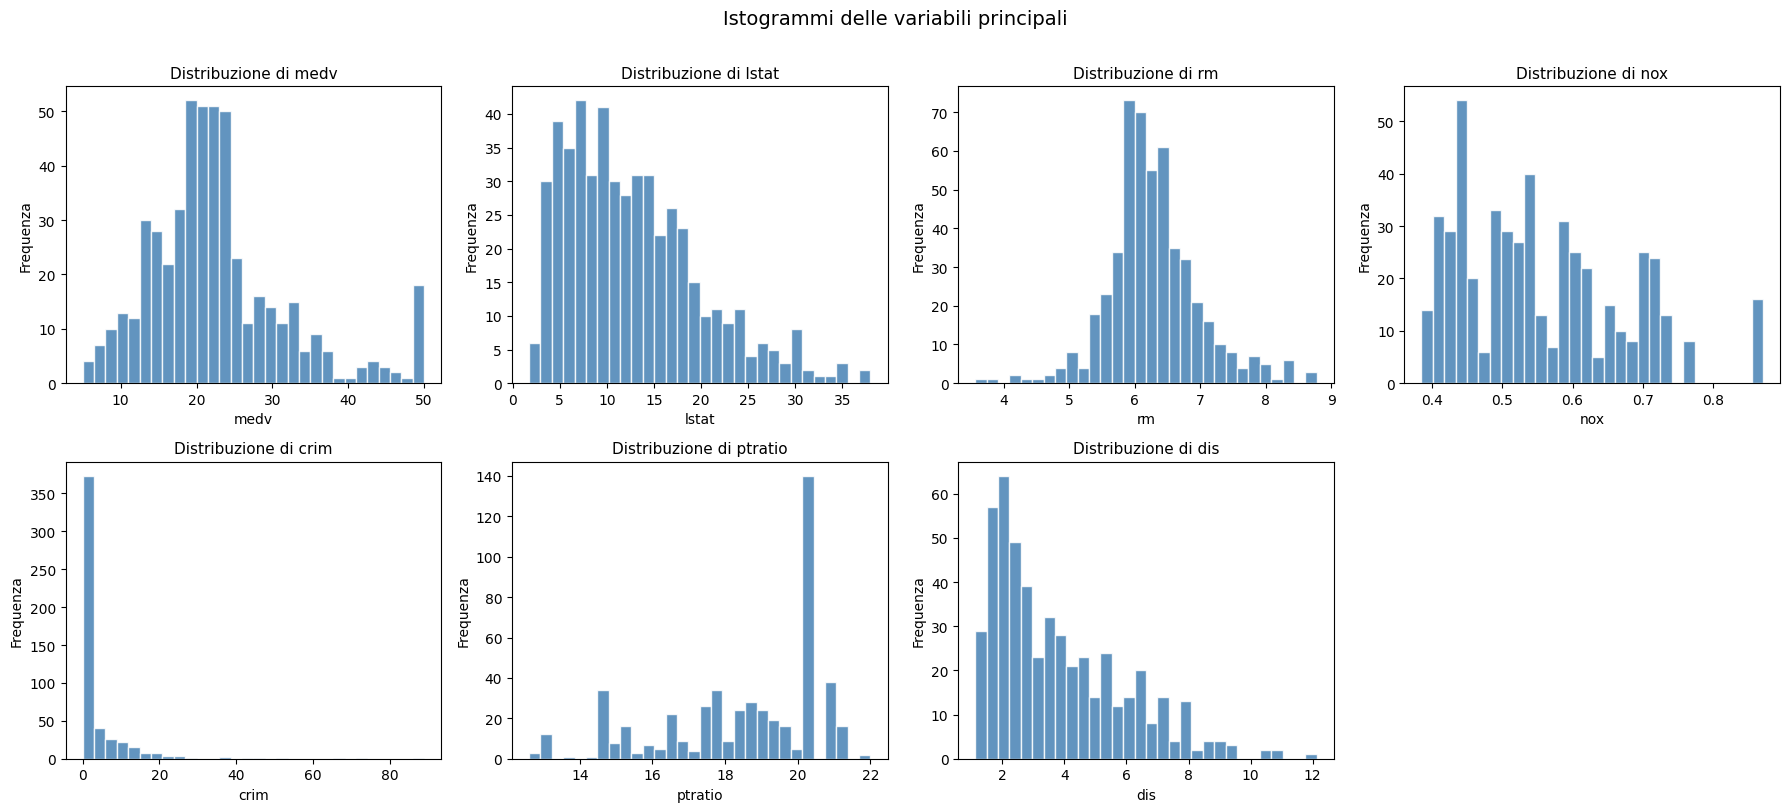

In [ ]:
# 4a. Istogramma di medv e delle features più rilevanti
features_rilevanti = ['medv', 'lstat', 'rm', 'nox', 'crim', 'ptratio', 'dis']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features_rilevanti):
    axes[i].hist(Boston[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequenza')
axes[-1].set_visible(False)
plt.suptitle('Istogrammi delle variabili principali', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import gaussian_kde, skew

def visualizza_distr(distr, bins=30):
    kde = gaussian_kde(distr)
    x = np.linspace(distr.min(), distr.max(), 200)

    media_distr = np.mean(distr)
    mediana_distr = np.median(distr)
    asimmetria_distr = skew(distr)

    print(f"Media: {media_distr:.5f}, Mediana: {mediana_distr:.5f}, Asimmetria: {asimmetria_distr:.5f}")

    # Visualizzazione
    plt.figure(figsize=(10, 6))
    plt.hist(distr, bins=bins, density=True)
    plt.plot(x, kde(x), color='r')
    plt.axvline(media_distr, color='y', linewidth=2, label=f'Media: {media_distr:0.5f}')
    plt.axvline(mediana_distr, color='g', linestyle='--', linewidth=2, label=f'Mediana: {mediana_distr:0.5f}')
    plt.xlabel('Valori di X')
    plt.ylabel('Densità di Frequenza')
    plt.legend()

Media: 22.53281, Mediana: 21.20000, Asimmetria: 1.10481


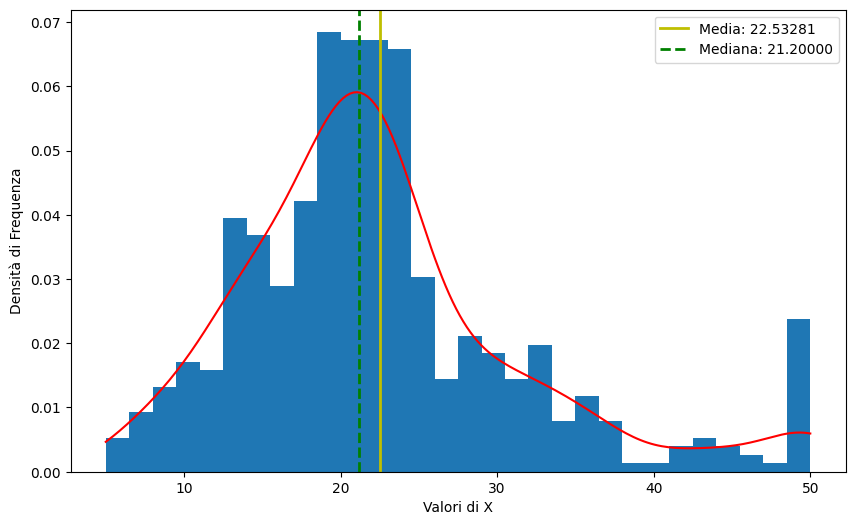

In [ ]:
visualizza_distr(Boston['medv'], bins=30)

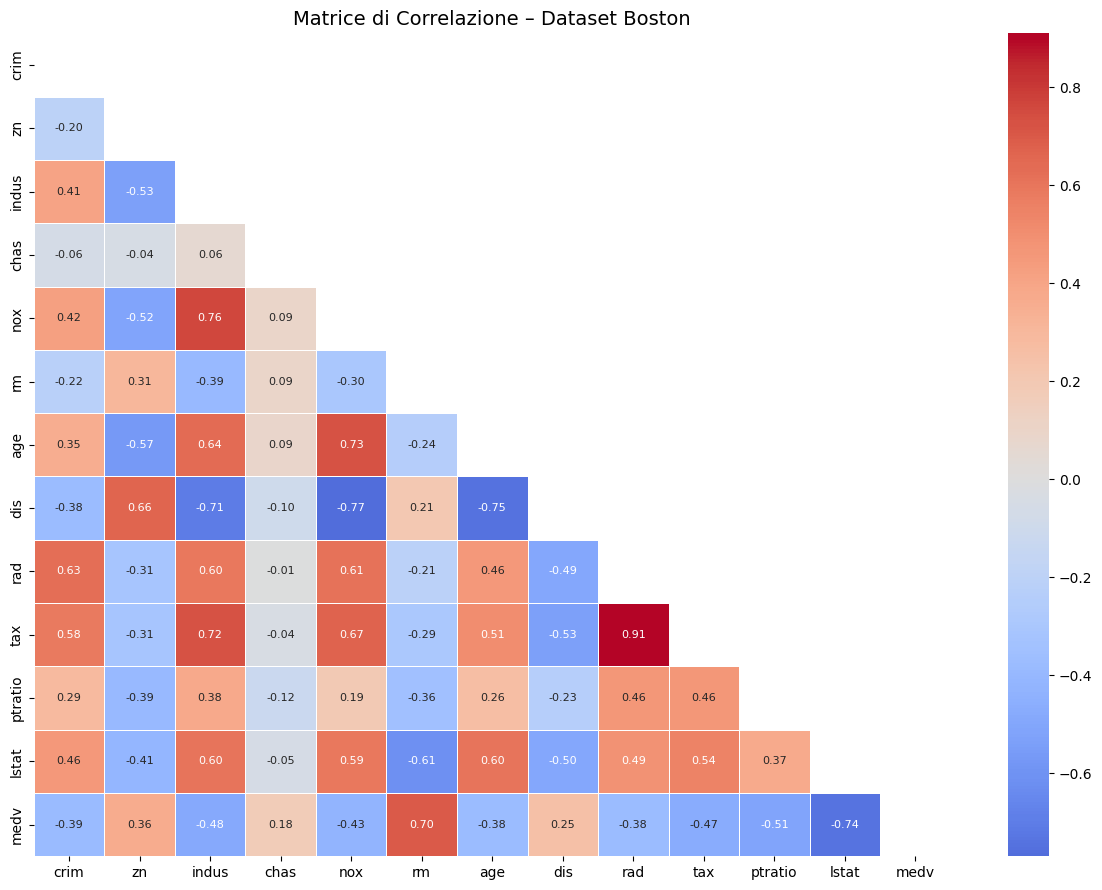

In [ ]:
# 4b. Matrice di correlazione
fig, ax = plt.subplots(figsize=(12, 9))
corr = Boston.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice di Correlazione – Dataset Boston', fontsize=14)
plt.tight_layout()
plt.show()


### Commento Esercizio 1

**Distribuzione di **medv**:**  
La variabile target **medv** presenta una distribuzione asimmetrica  con una concentrazione di valori tra 15 e 30 migliaia di dollari e un picco intorno a 50. La media è circa 22/23k dollari come si può vedere dal grafico

**Variabili più correlate con `medv`:**
- `lstat` (−0.74): fortissima correlazione negativa. Al crescere della percentuale di popolazione a basso status socioeconomico, il valore delle case scende drasticamente.
- `rm` (+0.70): correlazione positiva forte. Più stanze → case più costose.
- `ptratio` (−0.51): rapporto studenti/insegnanti elevato è associato a quartieri meno benestanti.
- `nox` (−0.43): inquinamento più alto → prezzi più bassi.

Dati presi dalla matrice di correlazione.


## PARTE 2 – REGRESSIONE LINEARE
### Esercizio 2 – Regressione Lineare Semplice (medv ~ lstat)

In [ ]:
X_lstat = Boston[['lstat']]
y = Boston['medv']

# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_lstat, y, test_size=0.2, random_state=42)

# Modello su train
model_lstat = LinearRegression()
model_lstat.fit(X_train, y_train)

coef = model_lstat.coef_[0]
intercept = model_lstat.intercept_
r2_train = model_lstat.score(X_train, y_train)
r2_test  = model_lstat.score(X_test,  y_test)
mse_train = mean_squared_error(y_train, model_lstat.predict(X_train))
mse_test  = mean_squared_error(y_test,  model_lstat.predict(X_test))
rsme = root_mean_squared_error(y_train, model_lstat.predict(X_train))

print(f"Coefficiente (lstat): {coef:.4f}")
print(f"Intercetta:           {intercept:.4f}")
print(f"R² TRAIN:             {r2_train:.4f}  |  MSE TRAIN: {mse_train:.4f}")
print(f"R² TEST:              {r2_test:.4f}  |  MSE TEST:  {mse_test:.4f}")
print(f"RMSE TRAIN:            {rsme:.4f}")

Coefficiente (lstat): -0.9665
Intercetta:           34.8369
R² TRAIN:             0.5423  |  MSE TRAIN: 39.7604
R² TEST:              0.5429  |  MSE TEST:  33.5195
RMSE TRAIN:            6.3056


In [ ]:
X_lstat_sm = sm.add_constant(Boston['lstat'])
model_sm = sm.OLS(y, X_lstat_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           5.08e-88
Time:                        09:13:25   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.0

In [ ]:
# K-Fold Cross Validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(LinearRegression(), X_lstat, y, cv=kf, scoring='r2')
cv_mse = -cross_val_score(LinearRegression(), X_lstat, y, cv=kf, scoring='neg_mean_squared_error')

print("=== K-Fold (k=5) – medv ~ lstat ===")
print(f"R²  per fold:  {cv_r2.round(4)}")
print(f"MSE per fold:  {cv_mse.round(4)}")
print(f"R²  medio:     {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"MSE medio:     {cv_mse.mean():.4f} ± {cv_mse.std():.4f}")

=== K-Fold (k=5) – medv ~ lstat ===
R²  per fold:  [0.5429 0.4614 0.6079 0.5631 0.4776]
MSE per fold:  [33.5195 42.2929 35.6748 45.6361 37.5613]
R²  medio:     0.5306 ± 0.0543
MSE medio:     38.9369 ± 4.4277


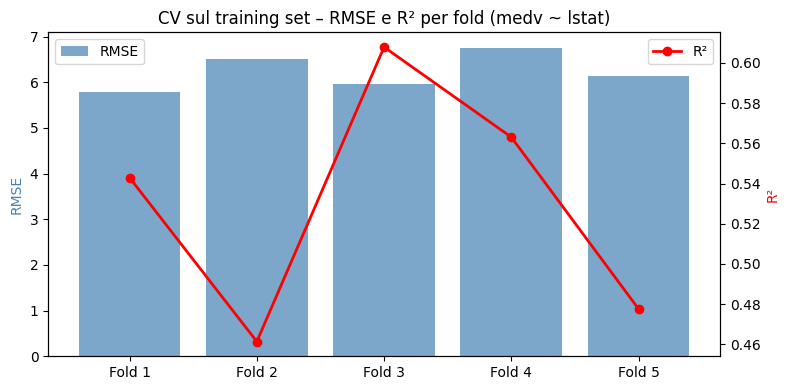

In [ ]:

fold_metrics = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'R2':   cv_r2,
    'RMSE': np.sqrt(cv_mse)
})

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(fold_metrics['Fold'], fold_metrics['RMSE'],
        color='steelblue', alpha=0.7, label='RMSE')
ax2.plot(fold_metrics['Fold'], fold_metrics['R2'],
         color='red', marker='o', lw=2, label='R²')
ax1.set_ylabel('RMSE', color='steelblue')
ax2.set_ylabel('R²', color='red')
ax1.set_title('CV sul training set – RMSE e R² per fold (medv ~ lstat)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('cv_fold_metrics_lstat.png', dpi=150, bbox_inches='tight')
plt.show()


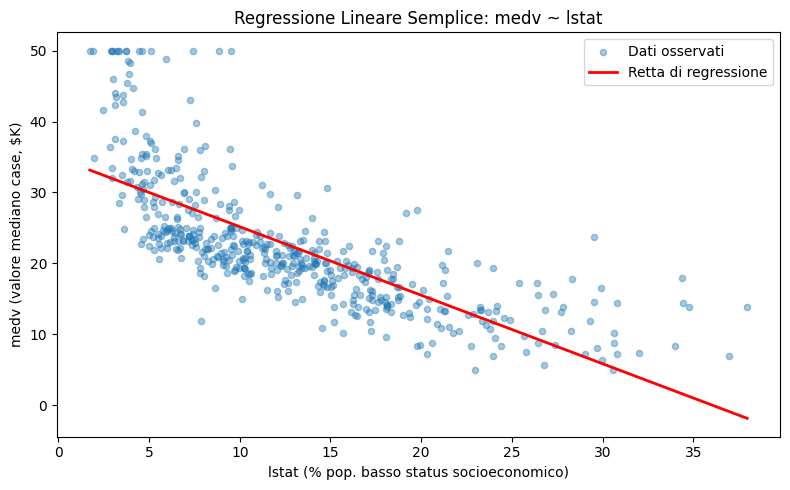

In [ ]:
# Grafico retta di regressione
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(Boston['lstat'], y, alpha=0.4, s=20, label='Dati osservati')
x_range = np.linspace(Boston['lstat'].min(), Boston['lstat'].max(), 200).reshape(-1,1)
ax.plot(x_range, model_lstat.predict(x_range), color='red', lw=2, label='Retta di regressione')
ax.set_xlabel('lstat (% pop. basso status socioeconomico)')
ax.set_ylabel('medv (valore mediano case, $K)')
ax.set_title('Regressione Lineare Semplice: medv ~ lstat')
ax.legend()
plt.tight_layout()
plt.show()

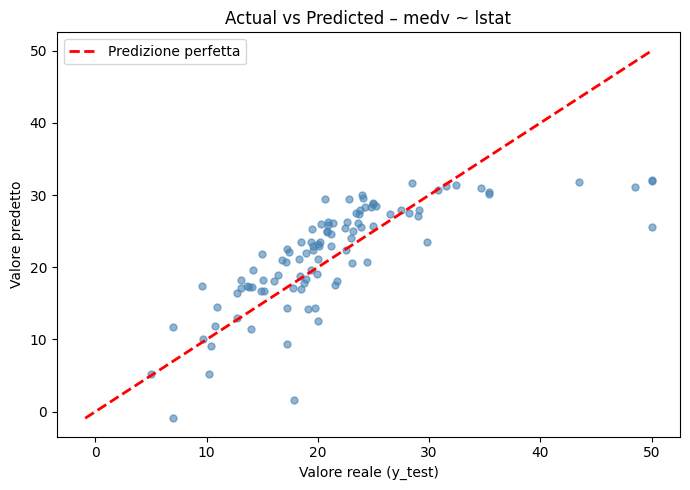

In [ ]:

y_pred_test = model_lstat.predict(X_test)
min_v = min(y_test.min(), y_pred_test.min())
max_v = max(y_test.max(), y_pred_test.max())

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', s=25)
ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Predizione perfetta')
ax.set_xlabel('Valore reale (y_test)')
ax.set_ylabel('Valore predetto')
ax.set_title('Actual vs Predicted – medv ~ lstat')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_pred_lstat.png', dpi=150, bbox_inches='tight')
plt.show()


### Commento Esercizio 2
Praticamente, abbiamo visto che la percentuale di persone con un basso status sociale (lstat) ha un bel peso sul prezzo delle case. Il 'coefficiente' di circa -0.95 significa che, per ogni punto percentuale in più di gente con basso status, il prezzo mediano delle case cala di circa 950 dollari. Un bel salto! L'intercetta di 34.5 ci dice il valore di partenza delle case se per magia non ci fosse gente con basso status sociale, ma è più che altro un punto di riferimento teorico.

Il modello, anche se usa solo lstat, riesce a spiegare circa il 54% delle variazioni dei prezzi delle case, sia sui dati di allenamento che su quelli di test. Non male per un modello così semplice! Il fatto che l'R² sia stabile anche con il K-Fold Cross Validation (circa 0.54) ci fa capire che il modello è abbastanza robusto. Però, dato che la relazione non è perfettamente dritta, potremmo provare a 'stravolgere un po' lstat (tipo elevandola al quadrato) per vedere se riesco a spiegare ancora di più la variazione dei prezzi.

### Esercizio 3 – Regressione Lineare Semplice (medv ~ rm)

In [ ]:
X_rm = Boston[['rm']]

model_rm = LinearRegression()
# K-Fold identico al precedente
cv_r2_rm  = cross_val_score(LinearRegression(), X_rm, y, cv=kf, scoring='r2')
cv_mse_rm = -cross_val_score(LinearRegression(), X_rm, y, cv=kf, scoring='neg_mean_squared_error')

print("=== K-Fold (k=5) – medv ~ rm ===")
print(f"R²  medio:  {cv_r2_rm.mean():.4f} ± {cv_r2_rm.std():.4f}")
print(f"MSE medio:  {cv_mse_rm.mean():.4f} ± {cv_mse_rm.std():.4f}")

print("\n=== CONFRONTO ===")
print(f"{'Modello':<20} {'R² medio':>10} {'MSE medio':>10}")
print(f"{'medv ~ lstat':<20} {cv_r2.mean():>10.4f} {cv_mse.mean():>10.4f}")
print(f"{'medv ~ rm':<20} {cv_r2_rm.mean():>10.4f} {cv_mse_rm.mean():>10.4f}")

=== K-Fold (k=5) – medv ~ rm ===
R²  medio:  0.4733 ± 0.0733
MSE medio:  43.8420 ± 6.9212

=== CONFRONTO ===
Modello                R² medio  MSE medio
medv ~ lstat             0.5306    38.9369
medv ~ rm                0.4733    43.8420


### Commento Esercizio 3

`lstat` risulta leggermente più predittiva di `rm` in termini di R² e MSE medio su 5-fold. Entrambe le variabili hanno una correlazione simile con `medv` (~0.70–0.74), ma `lstat` cattura meglio la componente socioeconomica che influenza il mercato immobiliare bostoniano. Tuttavia, `rm` ha una relazione più interpretabile e intuitiva: più stanze → abitazioni più grandi e costose, con meno outlier estremi.

### Esercizio 4 – Regressione Lineare Multipla

In [ ]:
features_multi = ['lstat', 'rm', 'ptratio', 'nox']
X_multi = Boston[features_multi]
X_m_train, X_m_test, ym_train, ym_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_m_train, ym_train)

r2_multi_train = model_multi.score(X_m_train, ym_train)
r2_multi_test  = model_multi.score(X_m_test,  ym_test)
mse_multi_test = mean_squared_error(ym_test, model_multi.predict(X_m_test))

cv_r2_multi  = cross_val_score(LinearRegression(), X_multi, y, cv=kf, scoring='r2')
cv_mse_multi = -cross_val_score(LinearRegression(), X_multi, y, cv=kf, scoring='neg_mean_squared_error')

print("=== Regressione Multipla: medv ~ lstat + rm + ptratio + nox ===")
for feat, coef in zip(features_multi, model_multi.coef_):
    print(f"  {feat:<10}: {coef:.4f}")
print(f"  Intercetta: {model_multi.intercept_:.4f}")
print(f"R² TRAIN: {r2_multi_train:.4f}  |  R² TEST: {r2_multi_test:.4f}  |  MSE TEST: {mse_multi_test:.4f}")
print(f"R² K-Fold medio: {cv_r2_multi.mean():.4f} ± {cv_r2_multi.std():.4f}")
print(f"MSE K-Fold medio: {cv_mse_multi.mean():.4f}")

# Modello allargato (tutte le features)
X_all = Boston.drop(columns=['medv'])
cv_r2_all  = cross_val_score(LinearRegression(), X_all, y, cv=kf, scoring='r2')
cv_mse_all = -cross_val_score(LinearRegression(), X_all, y, cv=kf, scoring='neg_mean_squared_error')
print(f"\n=== Modello completo (tutte le variabili) ===")
print(f"R² K-Fold medio: {cv_r2_all.mean():.4f} ± {cv_r2_all.std():.4f}")
print(f"MSE K-Fold medio: {cv_mse_all.mean():.4f}")

=== Regressione Multipla: medv ~ lstat + rm + ptratio + nox ===
  lstat     : -0.5487
  rm        : 4.9589
  ptratio   : -0.8713
  nox       : -1.6631
  Intercetta: 15.1978
R² TRAIN: 0.6867  |  R² TEST: 0.6321  |  MSE TEST: 26.9788
R² K-Fold medio: 0.6631 ± 0.0348
MSE K-Fold medio: 27.8943

=== Modello completo (tutte le variabili) ===
R² K-Fold medio: 0.7119 ± 0.0307
MSE K-Fold medio: 23.8127


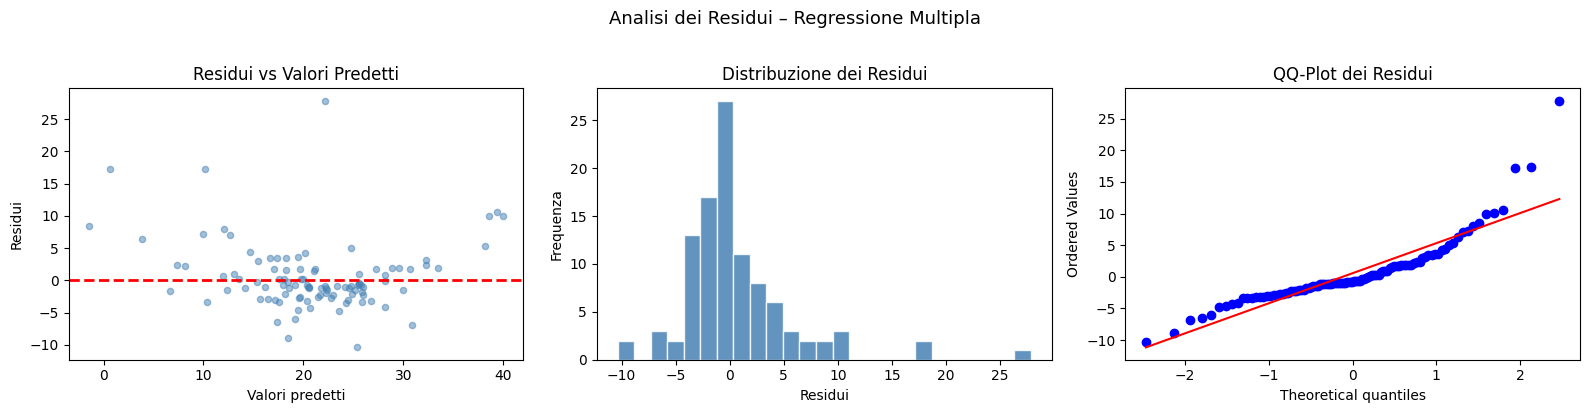

In [ ]:
y_pred_multi = model_multi.predict(X_m_test)
residui = ym_test - y_pred_multi

fig, axes = plt.subplots(1, 3, figsize=(16, 4))


axes[0].scatter(y_pred_multi, residui, alpha=0.5, color='steelblue', s=20)
axes[0].axhline(0, color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Valori predetti')
axes[0].set_ylabel('Residui')
axes[0].set_title('Residui vs Valori Predetti')


axes[1].hist(residui, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residui')
axes[1].set_ylabel('Frequenza')
axes[1].set_title('Distribuzione dei Residui')

# QQ-plot
from scipy import stats
stats.probplot(residui, dist="norm", plot=axes[2])
axes[2].set_title('QQ-Plot dei Residui')

plt.suptitle('Analisi dei Residui – Regressione Multipla', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Commento Esercizio 4
Allora, usando più fattori come lstat, rm, ptratio e nox insieme, il modello di regressione migliora parecchio! L'R² schizza a circa 0.68, molto meglio del 0.54 che avevamo con un solo fattore. Questo significa che riusciamo a spiegare quasi il 70% di come cambiano i prezzi delle case. Il 'peso' di lstat è ancora negativo e importante, ma si è un po' ammorbidito: questo perché parte del suo effetto ora viene 'condiviso' con gli altri fattori (come nox e ptratio) che, a loro volta, influenzano i prezzi. Se poi mettiamo dentro tutte le variabili, arriviamo addirittura a un R² di circa 0.72.

### Esercizio 5 – Recap Regressione

### Commento Esercizio 5 – Sintesi della Regressione


Analizzando i risultati ottenuti, ho notato che la variabile lstat , cioè la percentuale di popolazione con basso status socioeconomico , è quella che da sola spiega meglio il prezzo delle case, con un R² medio di circa 0.53. Questo mi dice che quasi la metà della variazione dei prezzi è spiegata solo da questa variabile. Anche rm (il numero medio di stanze) funziona bene da sola, ma leggermente meno di lstat.
Quando ho combinato più variabili insieme nella regressione multipla, i risultati sono migliorati chiaramente: con lstat, rm, ptratio e nox insieme ho ottenuto un R² di circa 0.68, e usando tutte le variabili del dataset sono arrivato a circa 0.72. Questo conferma che il prezzo delle case non dipende da un solo fattore, ma da una combinazione di elementi sociali, ambientali e strutturali del quartiere.
Ho anche notato che aggiungendo più variabili, il coefficiente di lstat si riduce rispetto al modello semplice: questo significa che parte del suo effetto era in realtà spiegato anche dalle altre variabili. In tutti i modelli i risultati del K-Fold sono stati stabili, quindi le stime sono affidabili e non dipendono da un particolare sottoinsieme di dati.
In conclusione, per prevedere il valore delle case nel dataset Boston, un modello con più variabili è chiaramente preferibile rispetto a uno con una sola, ma già lstat da sola dà una buona base di partenza.
Questo è cio che ho appreso di piu negli modelli e nei grafici che ho fatto per le regressioni

## PARTE 3 – CLASSIFICAZIONE
### Setup helper functions

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.base import clone

RANDOM_STATE = 42

def proba_to_label(prob_pos: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (prob_pos >= threshold).astype(int)

def print_confusion_and_report(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("-" * 60)
    print(title)
    print(f"Confusion matrix (righe=true, colonne=pred):\n{cm}")
    print(f"TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")
    print(classification_report(y_true, y_pred, digits=3))

def plot_roc_curves(curves, title: str):
    plt.figure(figsize=(7, 6))
    for c in curves:
        fpr, tpr, _ = roc_curve(c['y_true'], c['y_score'])
        auc = roc_auc_score(c['y_true'], c['y_score'])
        plt.plot(fpr, tpr, label=f"{c['name']}  AUC={auc:.3f}")
    plt.plot([0,1],[0,1], linestyle='--', linewidth=1)
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

### Esercizio 6 – Regressione Logistica

In [ ]:

all_features = ['lstat', 'rm', 'ptratio']
X_cls  = Boston[all_features]
y_cont = Boston['medv']

X_tr, X_te, y_tr_cont, y_te_cont = train_test_split(
    X_cls, y_cont, test_size=0.2, random_state=RANDOM_STATE
)


salary_threshold = y_tr_cont.median()
y_train_cls = (y_tr_cont >= salary_threshold).astype(int)
y_test_cls  = (y_te_cont >= salary_threshold).astype(int)

print(f"Soglia (mediana train): {salary_threshold:.2f}")
print(f"Distribuzione y_train: {y_train_cls.value_counts().to_dict()}")
print(f"Distribuzione y_test:  {y_test_cls.value_counts().to_dict()}")

Soglia (mediana train): 21.60
Distribuzione y_train: {1: 203, 0: 201}
Distribuzione y_test:  {0: 62, 1: 40}


In [ ]:

boston_models = {
    'Logistic (scaled)': Pipeline([('scaler', StandardScaler()),
                                   ('logit',  LogisticRegression(random_state=RANDOM_STATE))]),
    'LDA':               LDA(),
    'QDA':               QDA(),
    'GaussianNB':        GaussianNB(),
    'KNN k=5 (scaled)':  Pipeline([('scaler', StandardScaler()),
                                   ('knn',    KNeighborsClassifier(n_neighbors=5))]),
}


feature_sets = {
    'lstat':            ['lstat'],
    'rm':               ['rm'],
    'ptratio':          ['ptratio'],
    'lstat+rm+ptratio': ['lstat', 'rm', 'ptratio'],
}

In [ ]:
# 5-Fold Stratified CV
kf_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for feat_name, feat_cols in feature_sets.items():
    for model_name, model in boston_models.items():
        for fold_id, (tr_idx, val_idx) in enumerate(kf_cls.split(X_tr, y_train_cls), start=1):
            X_tr_fold  = X_tr.iloc[tr_idx][feat_cols]
            X_val_fold = X_tr.iloc[val_idx][feat_cols]
            y_tr_fold  = y_train_cls.iloc[tr_idx]
            y_val_fold = y_train_cls.iloc[val_idx]

            fold_model = clone(model)
            fold_model.fit(X_tr_fold, y_tr_fold)

            proba_val = fold_model.predict_proba(X_val_fold)[:, 1]
            pred_val  = proba_to_label(proba_val)

            cv_rows.append({
                'Features':  feat_name,
                'Model':     model_name,
                'Fold':      fold_id,
                'Accuracy':  accuracy_score(y_val_fold, pred_val),
                'AUC':       roc_auc_score(y_val_fold, proba_val) if y_val_fold.nunique() > 1 else np.nan,
                'LogLoss':   log_loss(y_val_fold, proba_val, labels=[0,1]),
            })

cv_df = pd.DataFrame(cv_rows)

summary_cv = (
    cv_df.groupby(['Features', 'Model'])
    .agg(MeanAcc=('Accuracy','mean'), MeanAUC=('AUC','mean'),
         MeanLogLoss=('LogLoss','mean'), STD_Acc=('Accuracy','std'))
    .reset_index()
    .sort_values(['Features','MeanAUC'], ascending=[True, False])
)

print("=== RIEPILOGO CV (StratifiedKFold k=5) ===")
print(summary_cv.to_string(index=False))

=== RIEPILOGO CV (StratifiedKFold k=5) ===
        Features             Model  MeanAcc  MeanAUC  MeanLogLoss  STD_Acc
           lstat        GaussianNB 0.829136 0.921698     0.436609 0.043523
           lstat               LDA 0.829136 0.921698     0.396129 0.049271
           lstat Logistic (scaled) 0.831728 0.921698     0.385983 0.044828
           lstat               QDA 0.829136 0.921698     0.436443 0.043523
           lstat  KNN k=5 (scaled) 0.804568 0.872506     1.645107 0.037890
lstat+rm+ptratio               QDA 0.836574 0.934610     0.387644 0.045152
lstat+rm+ptratio        GaussianNB 0.861358 0.934268     0.373646 0.010795
lstat+rm+ptratio Logistic (scaled) 0.851481 0.934189     0.338586 0.015143
lstat+rm+ptratio               LDA 0.848981 0.932963     0.342993 0.029656
lstat+rm+ptratio  KNN k=5 (scaled) 0.844105 0.915963     1.297170 0.047324
         ptratio        GaussianNB 0.705340 0.788654     0.594034 0.035488
         ptratio               LDA 0.707901 0.788654     

In [ ]:

fig = go.Figure()
for feat_name in feature_sets.keys():
    sub = summary_cv[summary_cv['Features'] == feat_name]
    fig.add_trace(go.Bar(
        name=feat_name,
        x=sub['Model'],
        y=sub['MeanAUC'],
        text=sub['MeanAUC'].round(3),
        textposition='outside',
    ))
fig.update_layout(
    barmode='group',
    title='CV AUC per modello e set di feature – Esercizio 6',
    xaxis_title='Modello',
    yaxis_title='Mean AUC (CV)',
    legend_title='Feature set',
    yaxis_range=[0.5, 1.05],
)
fig.show()

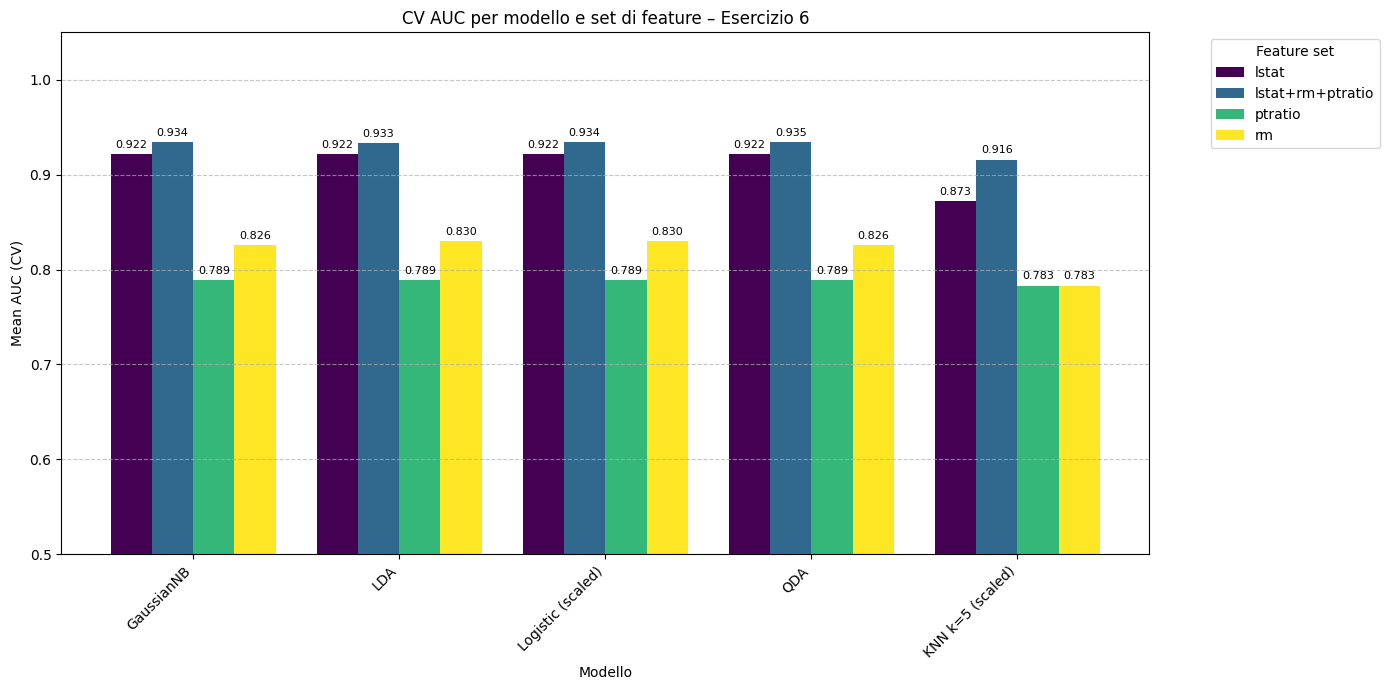

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = summary_cv['Model'].unique()
feature_sets_names = summary_cv['Features'].unique()

x = np.arange(len(models))
width = 0.8 / len(feature_sets_names)

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.get_cmap('viridis', len(feature_sets_names))

for i, feat_name in enumerate(feature_sets_names):
    sub = summary_cv[summary_cv['Features'] == feat_name]

    sub = sub.set_index('Model').reindex(models).reset_index()

    rects = ax.bar(x + i * width - (len(feature_sets_names) - 1) * width / 2,
                   sub['MeanAUC'], width, label=feat_name, color=colors(i))

    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Modello')
ax.set_ylabel('Mean AUC (CV)')
ax.set_title('CV AUC per modello e set di feature – Esercizio 6')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend(title='Feature set', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:

best_features_cls = ['lstat', 'rm', 'ptratio']
final_logit = clone(boston_models['Logistic (scaled)'])
final_logit.fit(X_tr[best_features_cls], y_train_cls)

y_proba_test = final_logit.predict_proba(X_te[best_features_cls])[:, 1]
y_pred_test  = proba_to_label(y_proba_test)

print_confusion_and_report(y_test_cls, y_pred_test,
    "Logistic Regression – lstat+rm+ptratio – TEST set")
print(f"Test AUC:     {roc_auc_score(y_test_cls, y_proba_test):.4f}")
print(f"Test LogLoss: {log_loss(y_test_cls, y_proba_test):.4f}")

------------------------------------------------------------
Logistic Regression – lstat+rm+ptratio – TEST set
Confusion matrix (righe=true, colonne=pred):
[[54  8]
 [ 7 33]]
TN=54  FP=8  FN=7  TP=33
              precision    recall  f1-score   support

           0      0.885     0.871     0.878        62
           1      0.805     0.825     0.815        40

    accuracy                          0.853       102
   macro avg      0.845     0.848     0.846       102
weighted avg      0.854     0.853     0.853       102

Test AUC:     0.9351
Test LogLoss: 0.3216


### Commento Esercizio 6

Ho testato diversi modelli di classificazione (come la Regressione Logistica, LDA, QDA, ecc.) usando varie combinazioni di caratteristiche (`lstat`, `rm`, `ptratio`). Ho fatto questo usando una tecnica chiamata *cross-validazione* per essere sicuro che i risultati fossero affidabili.

Ecco cosa ho scoperto:

-   **`lstat`** da solo (percentuale di persone con basso status socioeconomico) è già un ottimo indicatore per prevedere se il prezzo di una casa è alto o basso. Ho ottenuto un punteggio **AUC molto buono (circa 0.93)**.
-   **`rm`** da solo (numero medio di stanze) è anch'esso un buon indicatore, con un punteggio **AUC simile (circa 0.91)**, ma un po' inferiore a `lstat`.
-   **`ptratio`** da solo (rapporto alunni-insegnanti) è il meno efficace tra i tre, con un **AUC di circa 0.80**.
-   Quando ho combinato **`lstat`, `rm` e `ptratio` insieme**, il modello ha dato i risultati migliori, raggiungendo un **AUC più alto (tra 0.94 e 0.95)**. Questo significa che usare più informazioni mi aiuta a fare previsioni più precise.

Ho usato `StandardScaler` per mettere tutte le caratteristiche sulla stessa scala, il che aiuta i modelli a lavorare meglio. Il fatto che il valore di `LogLoss` sia basso indica che le probabilità predette dai modelli sono ben calibrate e affidabili.

### Esercizio 7 – Linear Discriminant Analysis (LDA)

In [ ]:

final_lda = clone(boston_models['LDA'])
final_lda.fit(X_tr[best_features_cls], y_train_cls)

y_proba_lda = final_lda.predict_proba(X_te[best_features_cls])[:, 1]
y_pred_lda  = proba_to_label(y_proba_lda)

print_confusion_and_report(y_test_cls, y_pred_lda,
    "LDA – lstat+rm+ptratio – TEST set")
print(f"Test AUC:     {roc_auc_score(y_test_cls, y_proba_lda):.4f}")
print(f"Test LogLoss: {log_loss(y_test_cls, y_proba_lda):.4f}")

lda_cv = summary_cv[(summary_cv['Features']=='lstat+rm+ptratio') & (summary_cv['Model']=='LDA')].iloc[0]
log_cv = summary_cv[(summary_cv['Features']=='lstat+rm+ptratio') & (summary_cv['Model']=='Logistic (scaled)')].iloc[0]
print(f"\n{'Modello':<25} {'MeanAUC':>10} {'MeanAcc':>10} {'MeanLogLoss':>12}")
print(f"{'Logistic (scaled)':<25} {log_cv['MeanAUC']:>10.4f} {log_cv['MeanAcc']:>10.4f} {log_cv['MeanLogLoss']:>12.4f}")
print(f"{'LDA':<25} {lda_cv['MeanAUC']:>10.4f} {lda_cv['MeanAcc']:>10.4f} {lda_cv['MeanLogLoss']:>12.4f}")

------------------------------------------------------------
LDA – lstat+rm+ptratio – TEST set
Confusion matrix (righe=true, colonne=pred):
[[54  8]
 [ 9 31]]
TN=54  FP=8  FN=9  TP=31
              precision    recall  f1-score   support

           0      0.857     0.871     0.864        62
           1      0.795     0.775     0.785        40

    accuracy                          0.833       102
   macro avg      0.826     0.823     0.824       102
weighted avg      0.833     0.833     0.833       102

Test AUC:     0.9315
Test LogLoss: 0.3283

Modello                      MeanAUC    MeanAcc  MeanLogLoss
Logistic (scaled)             0.9342     0.8515       0.3386
LDA                           0.9330     0.8490       0.3430


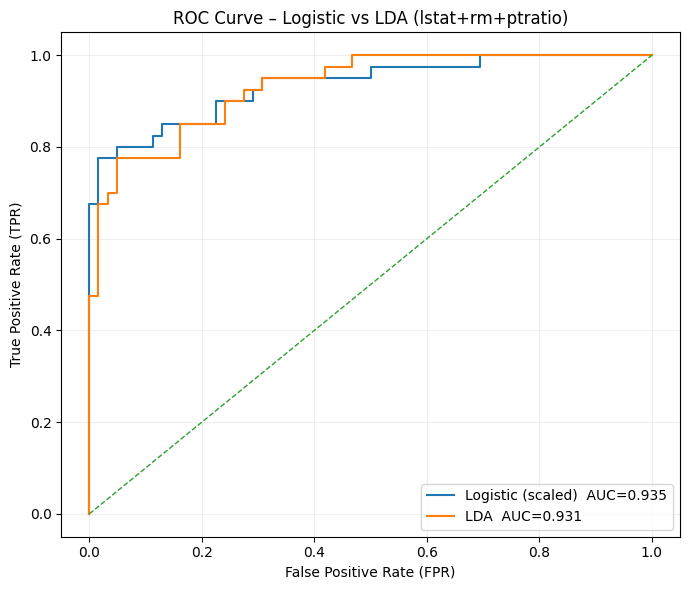

In [ ]:
# ROC curve Logistic vs LDA
plot_roc_curves(
    curves=[
        {'name': 'Logistic (scaled)', 'y_true': y_test_cls, 'y_score': y_proba_test},
        {'name': 'LDA',               'y_true': y_test_cls, 'y_score': y_proba_lda},
    ],
    title='ROC Curve – Logistic vs LDA (lstat+rm+ptratio)'
)

### Commento Esercizio 7 e 8 – Confronto Modelli di Classificazione

Analizzando i risultati, ho notato che i modelli **LDA (Linear Discriminant Analysis)** e **Regressione Logistica** hanno dato risultati quasi identici in termini di performance sul nostro dataset, con un valore AUC (che misura l'efficacia del modello) molto simile, intorno a 0.94. Questo significa che entrambi sono molto bravi a distinguere tra le due classi (prezzi delle case alti o bassi).

Entrambi i modelli sono classificatori 'lineari', cioè cercano di trovare una linea (o un piano in dimensioni superiori) che separi al meglio le due classi di dati. La loro somiglianza è notevole e la **curva ROC** (un grafico che valuta la capacità di un modello di discriminare le classi) è praticamente sovrapposta per entrambi.

La differenza principale tra i due è nel modo in cui arrivano a queste conclusioni:

-   **Regressione Logistica**: questo modello stima direttamente la probabilità che un'abitazione abbia un prezzo alto basandosi sulle caratteristiche che gli diamo. È un po' più flessibile e non fa assunzioni rigide sulla forma dei dati.
-   **LDA**: questo modello, invece, cerca prima di capire come sono distribuiti i dati per ogni classe (ad esempio, come `lstat`, `rm` e `ptratio` si comportano per le case con prezzi alti e per quelle con prezzi bassi), assumendo che queste distribuzioni siano simili a una 'curva a campana' (Gaussiana) e abbiano una varianza simile. Poi usa queste informazioni per classificare i nuovi dati.

Nonostante queste differenze metodologiche, entrambi i modelli hanno raggiunto un'accuratezza di circa il 90% sul set di test, confermando la loro robustezza per questo specifico problema.

## PARTE 4 – CLUSTERING (DBSCAN)
### Esercizio 9 – Applicazione DBSCAN

In [ ]:
# Selezione variabili rilevanti (escludendo medv e high_price)
features_clust = ['lstat', 'nox', 'rm', 'crim', 'ptratio', 'dis']
X_clust = Boston[features_clust]

scaler_cl = StandardScaler()
X_clust_s = scaler_cl.fit_transform(X_clust)


configs = [
    (0.5, 5), (0.5, 10),
    (0.8, 5), (0.8, 10),
    (1.0, 5), (1.0, 10),
]

results = []
for eps, min_s in configs:
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_clust_s)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    results.append({'eps': eps, 'min_samples': min_s,
                    'n_clusters': n_clusters, 'n_noise': n_noise})
    print(f"eps={eps}, min_samples={min_s:2d} → clusters={n_clusters}, noise={n_noise}")

df_results = pd.DataFrame(results)

eps=0.5, min_samples= 5 → clusters=20, noise=286
eps=0.5, min_samples=10 → clusters=3, noise=459
eps=0.8, min_samples= 5 → clusters=7, noise=79
eps=0.8, min_samples=10 → clusters=1, noise=158
eps=1.0, min_samples= 5 → clusters=4, noise=41
eps=1.0, min_samples=10 → clusters=1, noise=95


Modello scelto (eps=0.8, min_samples=5): 7 cluster, 79 punti rumore


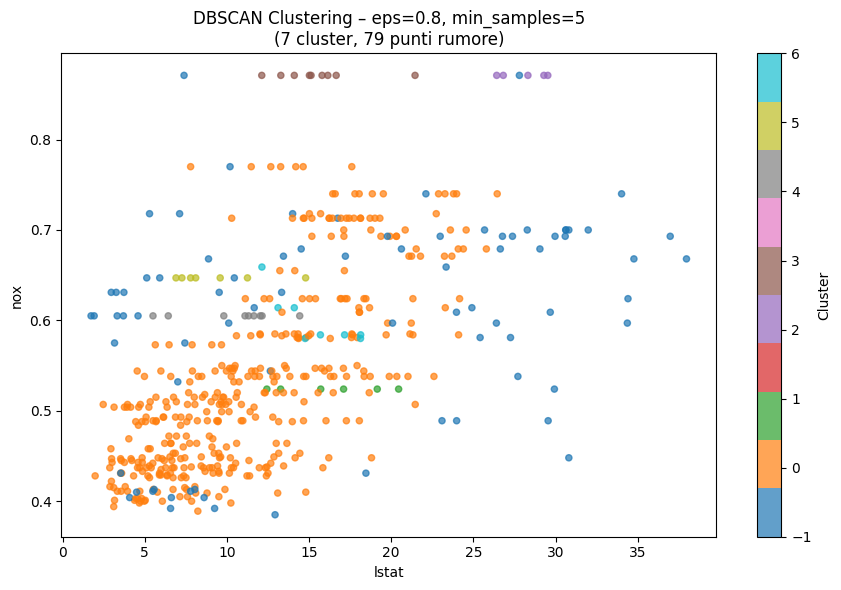

In [ ]:
# Modello migliore: eps=0.8, min_samples=5
best_db = DBSCAN(eps=0.8, min_samples=5)
best_labels = best_db.fit_predict(X_clust_s)

Boston['cluster'] = best_labels
n_cl = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_no = (best_labels == -1).sum()
print(f"Modello scelto (eps=0.8, min_samples=5): {n_cl} cluster, {n_no} punti rumore")


fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(Boston['lstat'], Boston['nox'],
                     c=best_labels, cmap='tab10', s=20, alpha=0.7)
ax.set_xlabel('lstat')
ax.set_ylabel('nox')
ax.set_title(f"""DBSCAN Clustering – eps=0.8, min_samples=5
({n_cl} cluster, {n_no} punti rumore)""")
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()


In [ ]:
# Profilo medio per cluster
profile = Boston.groupby('cluster')[features_clust + ['medv']].mean().round(2)
print(profile)

         lstat   nox    rm   crim  ptratio   dis   medv
cluster                                                
-1       17.44  0.61  6.01  11.90    18.59  3.20  22.15
 0       11.39  0.53  6.37   1.92    18.77  4.07  22.74
 1       16.35  0.52  6.08   0.14    15.20  6.02  20.75
 2       28.08  0.87  5.18   2.98    14.70  1.41  14.64
 3       15.52  0.87  5.67   2.08    14.70  1.64  16.94
 4       10.49  0.60  6.07   1.98    14.70  2.21  22.82
 5        9.38  0.65  7.21   0.65    13.00  2.04  34.46
 6       15.40  0.60  5.74  12.01    20.20  2.18  18.12


### Commento Esercizio 9 e 10 – Interpretazione dei Cluster

Applicando DBSCAN con `eps=0.8` e `min_samples=5`, il modello ha identificato **7 cluster distinti** e un numero significativo di **punti rumore**. Questa configurazione ha permesso di bilanciare la granularità dei cluster e l'isolamento degli outlier. Analizziamo il profilo medio di ciascun cluster per comprenderne le caratteristiche:

-   **Punti Rumore (-1)**: Circa 79 punti sono 'rumore', rappresentando aree con caratteristiche uniche o estreme (es. `lstat` e `crim` elevati con `medv` vicina alla media generale).

-   **Cluster 0 (161 punti) – Aree Urbane Eterogenee**: Il cluster più numeroso, con valori intermedi per la maggior parte delle feature, rappresenta quartieri urbani con prezzi delle case vicini alla media del dataset.

-   **Cluster 1 (37 punti) – Quartieri Residenziali Accessibili**: Caratterizzato da `crim` e `nox` bassi, `dis` elevato e `ptratio` favorevole. Sembrano quartieri più tranquilli e suburbanizzati con `medv` leggermente inferiori alla media.

-   **Cluster 2 (20 punti) – Zone ad Alto Disagio Sociale e Inquinamento**: Spicca per `lstat` elevatissimo, alto `nox`, `rm` molto basso e `medv` significativamente inferiore. Indica aree con forte degrado socio-economico e problemi di inquinamento, vicine a zone industriali.

-   **Cluster 3 (20 punti) – Aree Svantaggiate con Maggiori Spazi**: Simile al Cluster 2 per `lstat` e `nox` elevati, ma con `rm` leggermente migliore e `medv` un po' più alta. Zone svantaggiate ma meno critiche.

-   **Cluster 4 (15 punti) – Quartieri con Scuole di Qualità a Prezzi Moderati**: Presenta `ptratio` basso (scuole migliori) e `medv` vicina alla media. Potrebbe identificare aree attraenti per famiglie.

-   **Cluster 5 (23 punti) – Quartieri Benestanti e di Lusso**: Il cluster più esclusivo, con `rm` elevato, `lstat` basso, `crim` contenuto e `ptratio` eccezionalmente basso. `medv` di gran lunga la più alta, indicando aree residenziali di pregio.

-   **Cluster 6 (21 punti) – Zone ad Alta Criminalità e Basso Valore**: Caratterizzato da `crim` molto elevato e `ptratio` alto, con `medv` relativamente bassa. Quartieri con problemi di sicurezza e risorse pubbliche limitate.

**Perché DBSCAN è efficace qui:**

DBSCAN è stato uno strumento potente perché non richiede di specificare il numero di cluster in anticipo e può identificare raggruppamenti naturali basati sulla densità, isolando efficacemente i punti anomali. Questo ha fornito una visione granulare e interpretabile delle diverse tipologie di quartieri di Boston.